In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pycocotools
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Device:", device)

Device: cuda


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/XIS_AI_Project/MobilePhoneSegmentation.v1i.coco-segmentation.zip"

extract_dir = "/content/mobile_phone_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/mobile_phone_dataset"):
    print(root)

/content/mobile_phone_dataset
/content/mobile_phone_dataset/test
/content/mobile_phone_dataset/valid
/content/mobile_phone_dataset/train


In [ ]:
import os

print(os.path.exists("/content/mobile_phone_dataset/train/_annotations.coco.json"))
print(os.path.exists("/content/mobile_phone_dataset/valid/_annotations.coco.json"))
print(os.path.exists("/content/mobile_phone_dataset/test/_annotations.coco.json"))

True
True
True


In [ ]:
#dataset paths
DATASET_ROOT = "/content/mobile_phone_dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VALID_DIR = os.path.join(DATASET_ROOT, "valid")

TRAIN_JSON = os.path.join(
    TRAIN_DIR,
    "_annotations.coco.json"
)

VALID_JSON = os.path.join(
    VALID_DIR,
    "_annotations.coco.json"
)

In [ ]:
#custom COCO dataset class
class MobilePhoneDataset(Dataset):

    def __init__(self, image_dir, annotation_file):

        self.image_dir = image_dir

        self.coco = COCO(annotation_file)

        self.image_ids = list(
            self.coco.imgs.keys()
        )

    def __len__(self):

        return len(self.image_ids)

    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        image_info = self.coco.loadImgs(
            image_id
        )[0]

        image_path = os.path.join(
            self.image_dir,
            image_info["file_name"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        ann_ids = self.coco.getAnnIds(
            imgIds=image_id
        )

        anns = self.coco.loadAnns(
            ann_ids
        )

        masks = []
        boxes = []

        for ann in anns:

            mask = self.coco.annToMask(ann)

            masks.append(mask)

            pos = np.where(mask)

            xmin = np.min(pos[1])
            xmax = np.max(pos[1])

            ymin = np.min(pos[0])
            ymax = np.max(pos[0])

            boxes.append(
                [xmin, ymin, xmax, ymax]
            )

        masks = torch.as_tensor(
            np.array(masks),
            dtype=torch.uint8
        )

        boxes = torch.as_tensor(
            boxes,
            dtype=torch.float32
        )

        labels = torch.ones(
            (len(boxes),),
            dtype=torch.int64
        )

        target = {}

        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = torch.tensor(
            [image_id]
        )

        image = F.to_tensor(image)

        return image, target

In [ ]:
import os

for root, dirs, files in os.walk("/content/mobile_phone_dataset"):
    for file in files:
        if file.endswith(".json"):
            print(os.path.join(root, file))

/content/mobile_phone_dataset/test/_annotations.coco.json
/content/mobile_phone_dataset/valid/_annotations.coco.json
/content/mobile_phone_dataset/train/_annotations.coco.json


In [ ]:
import os

for root, dirs, files in os.walk("/content/mobile_phone_dataset"):
    print(root)

/content/mobile_phone_dataset
/content/mobile_phone_dataset/test
/content/mobile_phone_dataset/valid
/content/mobile_phone_dataset/train


In [ ]:
print(TRAIN_JSON)
print(VALID_JSON)

/content/mobile_phone_dataset/train/_annotations.coco.json
/content/mobile_phone_dataset/valid/_annotations.coco.json


In [ ]:
TRAIN_JSON = "/content/mobile_phone_dataset/train/_annotations.coco.json"
VALID_JSON = "/content/mobile_phone_dataset/valid/_annotations.coco.json"

print(TRAIN_JSON)
print(VALID_JSON)

/content/mobile_phone_dataset/train/_annotations.coco.json
/content/mobile_phone_dataset/valid/_annotations.coco.json


In [ ]:
print(MobilePhoneDataset)

<class '__main__.MobilePhoneDataset'>


In [ ]:
#load dataset
train_dataset = MobilePhoneDataset(
    "/content/mobile_phone_dataset/train",
    "/content/mobile_phone_dataset/train/_annotations.coco.json"
)

valid_dataset = MobilePhoneDataset(
    "/content/mobile_phone_dataset/valid",
    "/content/mobile_phone_dataset/valid/_annotations.coco.json"
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 56
Valid: 16


In [20]:
#dataloaders
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))

Train batches: 28
Valid batches: 8


In [21]:
#load pretrained mask R-CNN
import torchvision

from torchvision.models.detection import (
    maskrcnn_resnet50_fpn
)

model = maskrcnn_resnet50_fpn(
    weights="DEFAULT"
)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = \
torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

mask_in_features = \
model.roi_heads.mask_predictor.conv5_mask.in_channels

hidden_layer = 256

model.roi_heads.mask_predictor = \
torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    mask_in_features,
    hidden_layer,
    num_classes
)

model.to(device)

print("Mask R-CNN loaded successfully")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 132MB/s]


Mask R-CNN loaded successfully


In [22]:
#optimize
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.Adam(
    params,
    lr=0.0001
)

print("Optimizer created")

Optimizer created


In [23]:
#testing one batch only for now
images, targets = next(iter(train_loader))

images = [
    img.to(device)
    for img in images
]

targets = [
    {
        k: v.to(device)
        for k, v in t.items()
    }
    for t in targets
]

loss_dict = model(images, targets)

print(loss_dict)

{'loss_classifier': tensor(0.8054, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.2103, device='cuda:0', grad_fn=<DivBackward0>), 'loss_mask': tensor(5.9707, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(0.0014, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0019, device='cuda:0', grad_fn=<DivBackward0>)}


In [24]:
#function for training
def train_one_epoch(model, loader, optimizer, device):

    model.train()

    epoch_loss = 0

    for images, targets in loader:

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in t.items()
            }
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(
            loss
            for loss in loss_dict.values()
        )

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

    return epoch_loss / len(loader)

In [25]:
#function for validation
@torch.no_grad()
def validate_one_epoch(model, loader, device):

    model.train()

    val_loss = 0

    for images, targets in loader:

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in t.items()
            }
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(
            loss
            for loss in loss_dict.values()
        )

        val_loss += losses.item()

    return val_loss / len(loader)

In [27]:
EPOCHS = 10
train_losses = []
valid_losses = []

#training
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    valid_loss = validate_one_epoch(
        model,
        valid_loader,
        device
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Valid Loss: {valid_loss:.4f}"
    )

Epoch [1/10] Train Loss: 0.0804 Valid Loss: 0.1814
Epoch [2/10] Train Loss: 0.0764 Valid Loss: 0.1821
Epoch [3/10] Train Loss: 0.0730 Valid Loss: 0.1846
Epoch [4/10] Train Loss: 0.0694 Valid Loss: 0.1888
Epoch [5/10] Train Loss: 0.0704 Valid Loss: 0.1764
Epoch [6/10] Train Loss: 0.0733 Valid Loss: 0.2104
Epoch [7/10] Train Loss: 0.0683 Valid Loss: 0.1987
Epoch [8/10] Train Loss: 0.0734 Valid Loss: 0.2070
Epoch [9/10] Train Loss: 0.0677 Valid Loss: 0.1917
Epoch [10/10] Train Loss: 0.0720 Valid Loss: 0.1972


In [28]:
import os

save_path = "/content/drive/MyDrive/XIS_AI_Project/models/mask_rcnn_mobile_phone.pth"

torch.save(
    model.state_dict(),
    save_path
)

print("Model saved to:")
print(save_path)

Model saved to:
/content/drive/MyDrive/XIS_AI_Project/models/mask_rcnn_mobile_phone.pth


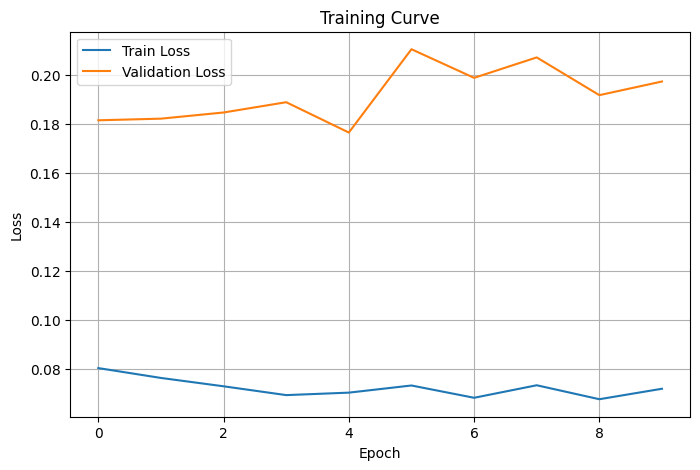

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    valid_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Curve")

plt.legend()

plt.grid()

plt.show()